# Bayesian Poisson inference and model mismatch

> A narrow uncertainty interval is only meaningful conditional on the model assumed for inference.

This final Issue-#4 notebook connects matched-model repeated-Poisson calibration to controlled decay-family and IRF-shape mismatch. It uses one short **illustrative** live posterior; all scientific calibration and mismatch results are loaded from completed, frozen Stage-5/6 artifacts. The corrected Stage-6.5 deterministic references are loaded separately. No multi-hour benchmark runs here.

The two questions are: (1) do model-conditional Bayesian and classical uncertainties track repeated-Poisson variability when the model is correct? (2) what happens to a seemingly precise lifetime when the assumed decay or fixed IRF is wrong?

See [Notebook 14](14_uncertainty_and_failure_awareness.ipynb) for Week-9 uncertainty/failure awareness and [Notebook 16](16_generalized_irf_and_failure_awareness.ipynb) for IRF source/preparation semantics.

In [1]:
import hashlib
import json
import math
from importlib.metadata import version
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tcspc_toolkit.bayesian import (
    BayesianModelContext, BayesianPriorConfig, BoundedUniformPrior,
    GammaPrior, IRFModelRelation, LogNormalPrior,
    fit_bayesian_monoexponential_reconvolution,
)
from tcspc_toolkit.bayesian_predictive import (
    sample_bayesian_posterior_predictive, sample_bayesian_prior_predictive,
)
from tcspc_toolkit.bayesian_sampling import BayesianSamplingConfig, BayesianSamplingStatus
from tcspc_toolkit.forward_model import monoexponential_reconvolution_expected_counts
from tcspc_toolkit.irf import generate_emg_irf_profile
from tcspc_toolkit.irf_preparation import prepare_irf
from tcspc_toolkit.measurements import MeasurementDataKind, TCSPCMeasurement
from tcspc_toolkit.simulation import sample_photon_counts

notebook_started = perf_counter()
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 6)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True})

## 1. Precomputed evidence and provenance

The Stage-5 and Stage-6 scientific profiles took hours and are **not** executed here. Their ignored outputs must already exist under `data/generated/issue4/`. Stage 6.5 corrected only the deterministic pseudo-true reference; it did not regenerate observations or rerun classical fits, bootstrap refits, MCMC, or PPC. This notebook requires the separate `scientific_reference_correction_v1.json` alongside the frozen Stage-6 outputs.

In a new clone, obtain the audited artifacts from the project run before running this notebook. For provenance, the original commands were `python scripts/run_issue4_bayesian_benchmarks.py --profile scientific` and `python scripts/run_issue4_bayesian_mismatch_benchmarks.py --profile scientific`; they are deliberately **not** invoked by any cell. The separate reference-only reanalysis was produced by `python scripts/correct_issue4_mismatch_references.py`; it, too, is not run here.

In [2]:
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'configs' / 'issue4_bayesian_workflow.json').is_file()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the repository or notebooks directory.')

paths = {
    'stage5_csv': repo_root / 'data/generated/issue4/scientific_realizations.csv',
    'stage5_json': repo_root / 'data/generated/issue4/scientific_summary.json',
    'stage6_csv': repo_root / 'data/generated/issue4/mismatch/scientific_realizations.csv',
    'stage6_json': repo_root / 'data/generated/issue4/mismatch/scientific_summary.json',
    'correction_v1': repo_root / 'data/generated/issue4/mismatch/scientific_reference_correction_v1.json',
    'stage5_manifest': repo_root / 'configs/issue4_bayesian_workflow.json',
    'stage6_manifest': repo_root / 'configs/issue4_bayesian_mismatch_workflow.json',
}
missing = [str(path.relative_to(repo_root)) for path in paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'Audited Issue-#4 artifacts are required; no scientific run is started. Missing: '
        + ', '.join(missing)
    )
sha256 = {name: hashlib.sha256(path.read_bytes()).hexdigest() for name, path in paths.items()}
stage5 = json.loads(paths['stage5_json'].read_text(encoding='utf-8'))
stage6 = json.loads(paths['stage6_json'].read_text(encoding='utf-8'))
correction = json.loads(paths['correction_v1'].read_text(encoding='utf-8'))
stage5_rows = pd.read_csv(paths['stage5_csv'])
stage6_rows = pd.read_csv(paths['stage6_csv'])
for name, path in (('stage6_csv', 'scientific_realizations.csv'),
                   ('stage6_json', 'scientific_summary.json')):
    assert sha256[name] == correction['provenance']['frozen_artifact_sha256'][path]
assert sha256['stage5_manifest'] == stage5['manifest_sha256']
assert sha256['stage6_manifest'] == stage6['manifest_sha256']
assert sha256['stage6_manifest'] == correction['provenance']['manifest_sha256']
assert len(stage5_rows) == 480 and len(stage6_rows) == 100
assert correction['saved_inference_records'] == 100
display(pd.DataFrame([
    {'artifact': name, 'SHA-256': digest, 'role': 'frozen inference' if name.endswith(('csv', 'json')) else 'reference correction'}
    for name, digest in sha256.items() if name in ('stage5_csv', 'stage5_json', 'stage6_csv', 'stage6_json', 'correction_v1')
]))
print('Toolkit', version('tcspc-lifetime-toolkit'),
      '| Stage-5 records', len(stage5_rows),
      '| Stage-6 observations', stage6['observations'],
      '| Stage-6 evaluations', len(stage6_rows))
print('Stage-5 seed policy:', json.loads(paths['stage5_manifest'].read_text(encoding='utf-8'))['randomness']['derivation'])
print('Stage-6 seed policy:', stage6['randomness']['namespace'], 'base seed', stage6['randomness']['base_seed'])

,artifact,SHA-256,role
0,stage5_csv,45e1d13f6d84d9ef9fbf1a83b30e2fbf7e37071afb70b3...,frozen inference
1,stage5_json,6b566cf216c4c02be138f7406f43a2f2c427cf683fb3c8...,frozen inference
2,stage6_csv,771bdf169f62ea35de65d8feb1255bbbf77cff4cf074e5...,frozen inference
3,stage6_json,aee4a1077051d78855a859850beef9cf333670d90d2efd...,frozen inference
4,correction_v1,c259af1706c71779702c1a15d5fdc9834db090548e652a...,reference correction


Toolkit 0.7.0 | Stage-5 records 480 | Stage-6 observations 80 | Stage-6 evaluations 100
Stage-5 seed policy: SHA-256 of issue4:v1:base_seed:condition_id:realization_index:stream:policy, first 64 bits little-endian
Stage-6 seed policy: issue4:stage6:v1 base seed 9406


## 2. Raw measurement, fixed IRF, and explicit priors

This small *independent synthetic demonstration* uses a raw Poisson histogram on a nanosecond grid. The EMG source is explicitly prepared into a fixed, unit-area IRF kernel. The canonical `TCSPCMeasurement` keeps unmodified integer counts; its known generating parameters remain outside the measurement object. Passing normalized or background-subtracted intensity to the Poisson inference API would violate the count model.

The assumed mean is `IRF_shift * [A exp(-t/tau)] + B`. Here `A` is the reconvolution scale (not detected photon count), `B` is counts/bin, and positive residual shift moves the model later. The fitted shift is separate from IRF-source preparation or registration.

,demonstration
measurement type,TCSPCMeasurement
data kind,raw_counts
bins,141
observed photon counts,18148
IRF source kind,synthetic_emg
prepared IRF area,1.0
known synthetic lifetime (ns),1.25


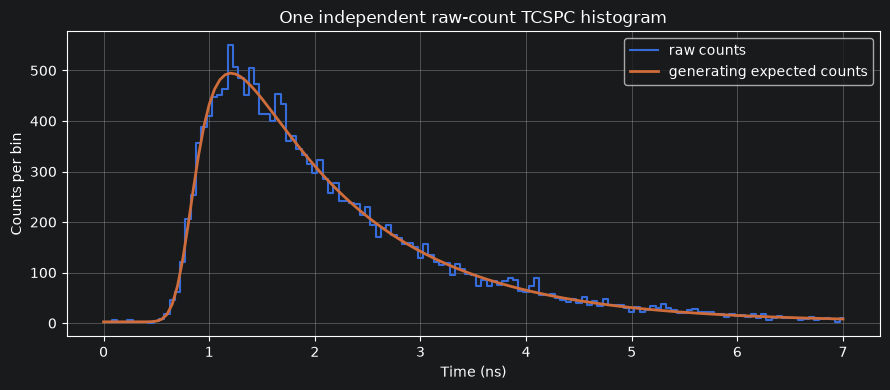

In [3]:
demo_time_ns = np.linspace(0.0, 7.0, 141)
demo_source_irf = generate_emg_irf_profile(
    demo_time_ns, gaussian_centre_ns=0.7,
    gaussian_fwhm_ns=0.25, tail_time_ns=0.20,
)
demo_prepared_irf = prepare_irf(demo_source_irf, demo_time_ns)
demo_generating = {'amplitude': 700.0, 'lifetime_ns': 1.25,
                   'background_per_bin': 2.5, 'temporal_shift_ns': 0.06}
demo_expected = monoexponential_reconvolution_expected_counts(
    demo_time_ns, demo_prepared_irf.kernel,
    amplitude=demo_generating['amplitude'],
    lifetime=demo_generating['lifetime_ns'],
    background=demo_generating['background_per_bin'],
    temporal_shift=demo_generating['temporal_shift_ns'],
)
demo_measurement = TCSPCMeasurement(
    time_ns=demo_time_ns,
    values=sample_photon_counts(demo_expected, np.random.default_rng(1824)),
    data_kind=MeasurementDataKind.RAW_COUNTS,
    sample_id='notebook17-independent-synthetic-demo',
    provenance={'origin': 'illustrative_synthetic', 'observation_seed': 1824},
)
assert np.issubdtype(demo_measurement.require_raw_counts().dtype, np.integer)
display(pd.Series({
    'measurement type': type(demo_measurement).__name__,
    'data kind': demo_measurement.data_kind.value,
    'bins': len(demo_time_ns),
    'observed photon counts': int(demo_measurement.require_raw_counts().sum()),
    'IRF source kind': demo_prepared_irf.source.source_kind.value,
    'prepared IRF area': demo_prepared_irf.diagnostics.target_area_after_normalization,
    'known synthetic lifetime (ns)': demo_generating['lifetime_ns'],
}).to_frame('demonstration'))
fig, ax = plt.subplots()
ax.step(demo_time_ns, demo_measurement.require_raw_counts(), where='mid', label='raw counts')
ax.plot(demo_time_ns, demo_expected, label='generating expected counts', lw=2)
ax.set(xlabel='Time (ns)', ylabel='Counts per bin', title='One independent raw-count TCSPC histogram')
ax.legend()
fig.tight_layout()
plt.show()

In [4]:
demo_priors = BayesianPriorConfig(
    amplitude=GammaPrior(shape=4.0, rate=4.0 / 700.0),
    lifetime_ns=LogNormalPrior(log_mean=math.log(1.25), log_std=0.5),
    background_per_bin=GammaPrior(shape=2.0, rate=2.0 / 2.5),
    temporal_shift_prior=BoundedUniformPrior(-0.2, 0.2),
    fixed_temporal_shift_ns=None,
)
display(pd.DataFrame([
    {'parameter': 'A', 'unit': 'reconvolution scale', 'prior': 'Gamma(shape=4, rate=4/700)'},
    {'parameter': 'tau', 'unit': 'ns', 'prior': 'LogNormal(log-mean=log(1.25), log-SD=0.5)'},
    {'parameter': 'B', 'unit': 'counts/bin', 'prior': 'Gamma(shape=2, rate=2/2.5)'},
    {'parameter': 'residual shift', 'unit': 'ns', 'prior': 'Uniform[-0.2, 0.2]'},
]))
print('These illustrative priors are specified explicitly, not fitted from the observed histogram.')

,parameter,unit,prior
0,A,reconvolution scale,"Gamma(shape=4, rate=4/700)"
1,tau,ns,"LogNormal(log-mean=log(1.25), log-SD=0.5)"
2,B,counts/bin,"Gamma(shape=2, rate=2/2.5)"
3,residual shift,ns,"Uniform[-0.2, 0.2]"


These illustrative priors are specified explicitly, not fitted from the observed histogram.


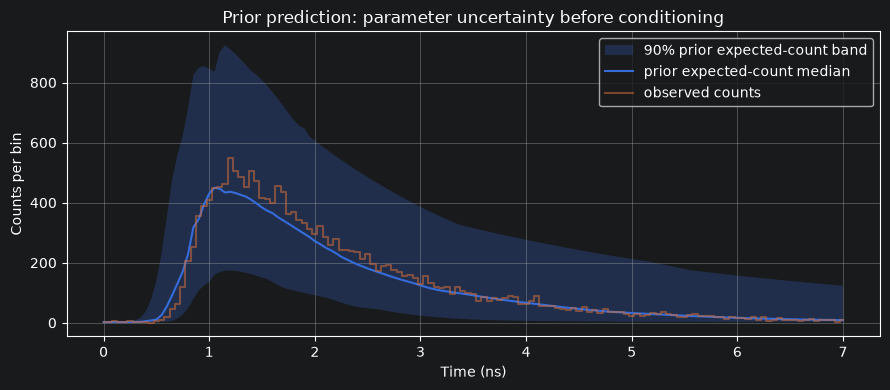

This is a prior-predictive illustration, not an interval-calibration test.


In [5]:
demo_context = BayesianModelContext(
    demo_measurement, prepared_irf=demo_prepared_irf,
    irf_model_relation=IRFModelRelation.MATCHED,
)
demo_prior_predictive = sample_bayesian_prior_predictive(
    demo_context, demo_priors, n_draws=80, random_seed=1801, interval_level=0.90,
)
prior_band = demo_prior_predictive.prior_expected_count_band
fig, ax = plt.subplots()
ax.fill_between(demo_time_ns, prior_band.lower, prior_band.upper, alpha=0.25,
                label='90% prior expected-count band')
ax.plot(demo_time_ns, prior_band.median, label='prior expected-count median')
ax.step(demo_time_ns, demo_measurement.require_raw_counts(), where='mid',
        alpha=0.55, label='observed counts')
ax.set(xlabel='Time (ns)', ylabel='Counts per bin',
       title='Prior prediction: parameter uncertainty before conditioning')
ax.legend()
fig.tight_layout()
plt.show()
print('This is a prior-predictive illustration, not an interval-calibration test.')

## 3. One short live posterior (demonstration only)

Two independent ensembles sample the four-parameter posterior for this single histogram. The 16-walker, 70-step warmup and 130-step production budget uses **relaxed demonstration diagnostics** to keep fresh-kernel execution practical. It is not the Stage-5/6 scientific sampler policy and must not be used for coverage or physical-validity claims. The fixed random seed is independent of the scientific benchmark streams.

In [6]:
demo_sampling = BayesianSamplingConfig(
    random_seed=36, n_walkers=16, warmup_steps=70,
    production_steps=130, max_production_steps=130,
    extension_steps=40, n_ensembles=2, credible_interval_level=0.90,
    min_autocorrelation_multiples=2.0,
    max_autocorrelation_relative_change=5.0,
    min_effective_samples=10.0,
    max_ensemble_location_difference_sd=3.0,
    min_mean_acceptance_fraction=0.01,
    max_mean_acceptance_fraction=0.99,
)
demo_run = fit_bayesian_monoexponential_reconvolution(
    demo_measurement, priors=demo_priors, sampling_config=demo_sampling,
    prepared_irf=demo_prepared_irf, irf_model_relation=IRFModelRelation.MATCHED,
)
demo_result = demo_run.result
diag = demo_result.diagnostics
display(pd.DataFrame([vars(summary) for summary in demo_result.parameter_summaries]).round(5))
display(pd.Series({
    'status': demo_result.status.value,
    'production steps per ensemble': diag.production_steps,
    'extensions': diag.extension_count,
    'mean acceptance fraction': diag.mean_acceptance_fraction,
    'minimum approximate ESS': float(np.nanmin(diag.approximate_effective_samples)),
    'maximum estimated autocorrelation time (steps)': float(np.nanmax(diag.autocorrelation_time_steps)),
    'maximum full-vs-half autocorrelation change': float(np.nanmax(diag.autocorrelation_relative_change)),
    'maximum ensemble mean difference / pooled SD': diag.maximum_ensemble_mean_difference_sd,
    'failure reasons': diag.failure_reasons,
    'inference seconds': demo_result.runtime.total_seconds,
}).to_frame('illustrative run'))
assert demo_result.status is BayesianSamplingStatus.SUCCESS, diag.failure_reasons

,name,unit,mean,median,standard_deviation,credible_lower,credible_upper
0,amplitude,reconvolution_scale,700.41683,699.94127,9.58865,685.56429,716.87975
1,lifetime_ns,ns,1.25354,1.25396,0.01768,1.22495,1.28113
2,background_per_bin,counts_per_bin,3.37159,3.08260,1.05600,2.25886,5.84511
3,temporal_shift_ns,ns,0.05879,0.05837,0.00469,0.05152,0.06696


,illustrative run
status,success
production steps per ensemble,130
extensions,0
mean acceptance fraction,0.573798
minimum approximate ESS,315.251641
maximum estimated autocorrelation time (steps),17.065385
maximum full-vs-half autocorrelation change,0.541433
maximum ensemble mean difference / pooled SD,0.910811
failure reasons,()
inference seconds,1.781404


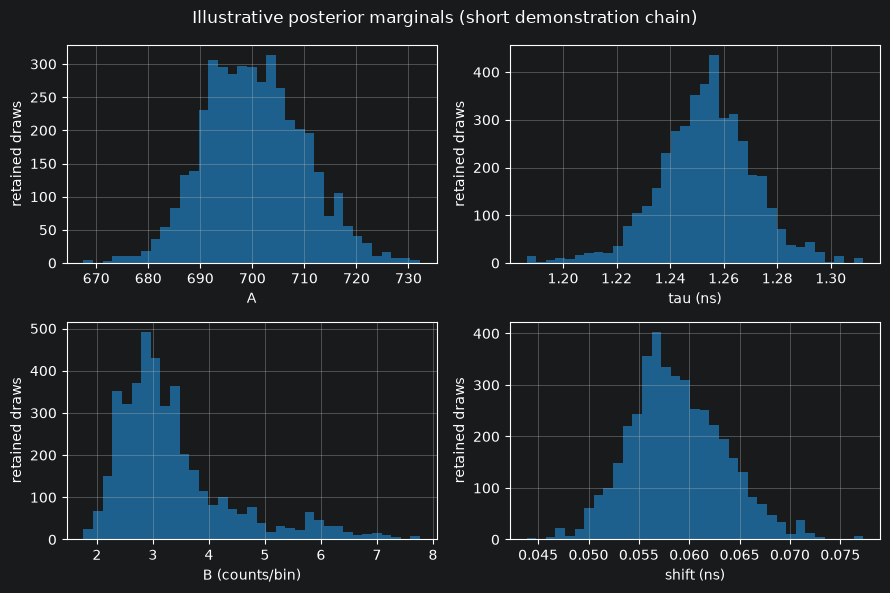

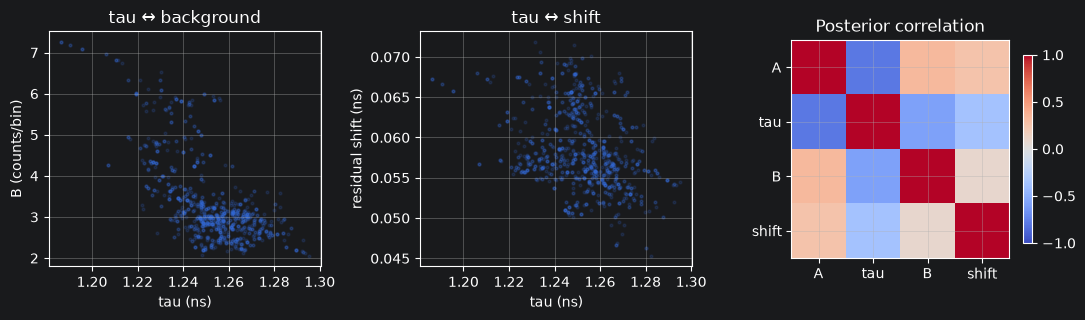

tau-background correlation: -0.581 | tau-shift correlation: -0.365
These describe posterior parameter tradeoffs, not causal effects.


In [7]:
demo_draws = demo_run.samples.physical.reshape(-1, 4)
demo_names = ['A', 'tau (ns)', 'B (counts/bin)', 'shift (ns)']
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for index, ax in enumerate(axes.flat):
    ax.hist(demo_draws[:, index], bins=35, color='tab:blue', alpha=0.75)
    ax.set(xlabel=demo_names[index], ylabel='retained draws')
fig.suptitle('Illustrative posterior marginals (short demonstration chain)')
fig.tight_layout()
plt.show()

corr = demo_result.correlation_matrix
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
axes[0].scatter(demo_draws[::4, 1], demo_draws[::4, 2], s=4, alpha=0.15)
axes[0].set(xlabel='tau (ns)', ylabel='B (counts/bin)', title='tau ↔ background')
axes[1].scatter(demo_draws[::4, 1], demo_draws[::4, 3], s=4, alpha=0.15)
axes[1].set(xlabel='tau (ns)', ylabel='residual shift (ns)', title='tau ↔ shift')
image = axes[2].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[2].set(xticks=range(4), yticks=range(4),
            xticklabels=['A', 'tau', 'B', 'shift'],
            yticklabels=['A', 'tau', 'B', 'shift'],
            title='Posterior correlation')
fig.colorbar(image, ax=axes[2], shrink=0.8)
fig.tight_layout()
plt.show()
print('tau-background correlation:', round(float(corr[1, 2]), 3),
      '| tau-shift correlation:', round(float(corr[1, 3]), 3))
print('These describe posterior parameter tradeoffs, not causal effects.')

## 4. Posterior prediction on the same live histogram

The library propagates the retained posterior draws through the fixed-IRF forward model. The expected-count band represents uncertainty in the latent mean curve. The replicated-count band also includes fresh Poisson noise; it is therefore wider. PPC tail fractions are descriptive, model-conditional comparisons, not universally calibrated frequentist p-values or binary model-validity decisions.

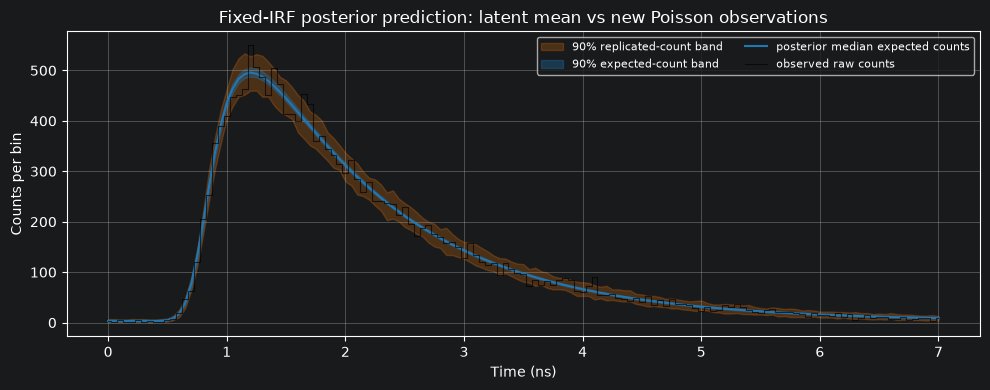

,discrepancy,posterior-predictive tail fraction
0,Poisson deviance,0.325
1,"tail-window [4, 7) ns counts",0.438
2,peak counts,0.038


In [8]:
demo_ppc = sample_bayesian_posterior_predictive(
    demo_run, n_draws=80, random_seed=1802, interval_level=0.90,
    early_window_ns=(0.7, 2.0), tail_window_ns=(4.0, 7.0),
)
expected_band = demo_ppc.posterior_expected_count_band
replicated_band = demo_ppc.posterior_predictive_count_band
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(demo_time_ns, replicated_band.lower, replicated_band.upper,
                color='tab:orange', alpha=0.22, label='90% replicated-count band')
ax.fill_between(demo_time_ns, expected_band.lower, expected_band.upper,
                color='tab:blue', alpha=0.32, label='90% expected-count band')
ax.plot(demo_time_ns, expected_band.median, color='tab:blue', lw=1.5,
        label='posterior median expected counts')
ax.step(demo_time_ns, demo_measurement.require_raw_counts(), where='mid',
        color='black', alpha=0.65, lw=0.8, label='observed raw counts')
ax.set(xlabel='Time (ns)', ylabel='Counts per bin',
       title='Fixed-IRF posterior prediction: latent mean vs new Poisson observations')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
ppc_diag = demo_ppc.diagnostics
display(pd.DataFrame([
    {'discrepancy': 'Poisson deviance',
     'posterior-predictive tail fraction': ppc_diag.poisson_deviance.posterior_predictive_tail_probability},
    {'discrepancy': 'tail-window [4, 7) ns counts',
     'posterior-predictive tail fraction': ppc_diag.windows[1].total_counts.posterior_predictive_tail_probability},
    {'discrepancy': 'peak counts',
     'posterior-predictive tail fraction': ppc_diag.peak_counts.posterior_predictive_tail_probability},
]).round(3))

## 5. Stage-5 matched-model repeated-Poisson calibration

The **scientific** Stage-5 output contains eight mono-exponential/IRF-matched conditions with 50 Poisson observations each, plus four predeclared 20-observation prior-sensitivity jobs. The comparisons below use only the 400 baseline observations. All methods saw the same raw histogram per realization. Local Poisson/Fisher covariance intervals, 100-refit parametric-bootstrap percentile intervals, and Bayesian equal-tailed credible intervals are distinct objects, each at nominal 90%.

For covariance and bootstrap, the empirical denominator is the repeated-dataset spread of **classical fits**. For Bayesian posterior SD, it is the spread of **posterior medians**. With only 50 realizations per condition, interval-inclusion differences of a few observations should not be ranked as method performance.

,photons,method,mean reported SD (ns),empirical estimator spread (ns),mean interval width (ns),reference included,Wilson 95% interval
0,1000,covariance,0.1100,0.1268,0.3617,42/50,"[0.71, 0.92]"
1,1000,bootstrap,0.1127,0.1268,0.3589,42/50,"[0.71, 0.92]"
2,1000,bayesian,0.1087,0.1255,0.3572,42/48,"[0.75, 0.94]"
3,10000,covariance,0.0258,0.0299,0.0848,42/50,"[0.71, 0.92]"
4,10000,bootstrap,0.0260,0.0299,0.0840,41/50,"[0.69, 0.90]"
5,10000,bayesian,0.0259,0.0301,0.0853,40/49,"[0.69, 0.90]"
6,100000,covariance,0.0073,0.0075,0.0240,44/50,"[0.76, 0.94]"
7,100000,bootstrap,0.0074,0.0075,0.0235,41/50,"[0.69, 0.90]"
8,100000,bayesian,0.0073,0.0075,0.0240,44/50,"[0.76, 0.94]"


All 24 baseline Wilson intervals contain nominal 0.90.


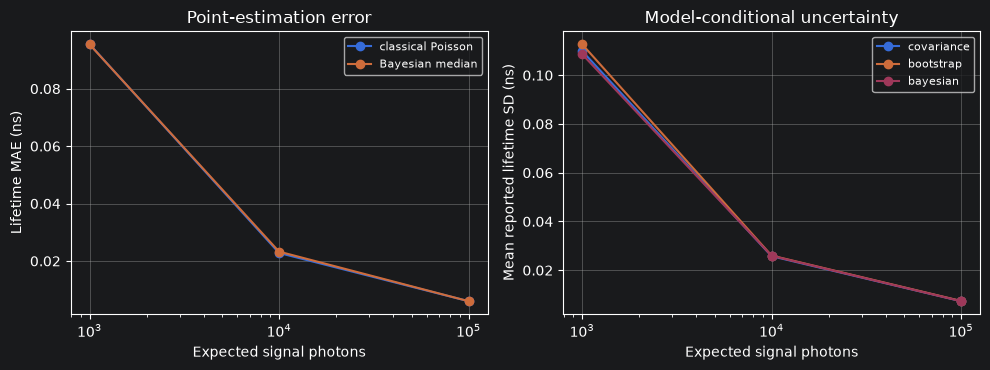

In [9]:
baseline = {
    item['condition_id']: item for item in stage5['summaries']
    if item['prior_policy_id'] == 'baseline'
}
assert len(baseline) == 8
photon_conditions = ['tau2_n1000_b0p5', 'tau2_n10000_b0p5', 'tau2_n100000_b0p5']
photon_table = []
for condition_id in photon_conditions:
    summary = baseline[condition_id]
    for interval, scale in zip(summary['intervals'], summary['uncertainty_scale_comparisons']):
        assert interval['method'] == scale['method']
        photon_table.append({
            'photons': int(condition_id.split('_')[1][1:]),
            'method': interval['method'],
            'mean reported SD (ns)': scale['mean_reported_lifetime_std_ns'],
            'empirical estimator spread (ns)': scale['empirical_estimator_spread_ns'],
            'mean interval width (ns)': interval['mean_width_ns'],
            'reference included': f"{interval['n_covering']}/{interval['n_valid']}",
            'Wilson 95% interval': f"[{interval['wilson_95_lower']:.2f}, {interval['wilson_95_upper']:.2f}]",
        })
display(pd.DataFrame(photon_table).round(4))
assert all(
    interval['wilson_95_lower'] <= 0.90 <= interval['wilson_95_upper']
    for summary in baseline.values() for interval in summary['intervals']
)
print('All 24 baseline Wilson intervals contain nominal 0.90.')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
photons = [1000, 10000, 100000]
for estimator, label in [('classical_fit', 'classical Poisson'),
                         ('bayesian_posterior_median', 'Bayesian median')]:
    mae = [next(item['empirical_mae_ns'] for item in baseline[c]['estimator_spreads']
                if item['estimator'] == estimator) for c in photon_conditions]
    axes[0].plot(photons, mae, marker='o', label=label)
for method in ('covariance', 'bootstrap', 'bayesian'):
    values = [next(item['mean_reported_lifetime_std_ns']
                   for item in baseline[c]['uncertainty_scale_comparisons']
                   if item['method'] == method) for c in photon_conditions]
    axes[1].plot(photons, values, marker='o', label=method)
for ax in axes:
    ax.set(xscale='log', xlabel='Expected signal photons')
    ax.legend(fontsize=8)
axes[0].set(ylabel='Lifetime MAE (ns)', title='Point-estimation error')
axes[1].set(ylabel='Mean reported lifetime SD (ns)', title='Model-conditional uncertainty')
fig.tight_layout()
plt.show()

In [10]:
background_rows = []
for condition_id, label in [('tau2_n10000_b0p5', 'B = 0.5 counts/bin'),
                            ('tau2_n10000_b5', 'B = 5 counts/bin')]:
    summary = baseline[condition_id]
    background_rows.append({
        'condition': label,
        'classical MAE (ns)': next(x['empirical_mae_ns'] for x in summary['estimator_spreads']
                                   if x['estimator'] == 'classical_fit'),
        'Bayesian-median MAE (ns)': next(x['empirical_mae_ns'] for x in summary['estimator_spreads']
                                         if x['estimator'] == 'bayesian_posterior_median'),
        'covariance SD (ns)': summary['mean_reported_lifetime_std_ns'][0][1],
        'bootstrap SD (ns)': summary['mean_reported_lifetime_std_ns'][1][1],
        'Bayesian SD (ns)': summary['mean_reported_lifetime_std_ns'][2][1],
        'mean corr(tau, B)': summary['mean_lifetime_background_correlation'],
        'mean corr(tau, shift)': summary['mean_lifetime_shift_correlation'],
    })
display(pd.DataFrame(background_rows).round(4))
print('Higher background broadens uncertainty and changes parameter coupling; the posterior correlations expose tradeoffs hidden by one marginal lifetime interval.')

,condition,classical MAE (ns),Bayesian-median MAE (ns),covariance SD (ns),bootstrap SD (ns),Bayesian SD (ns),"mean corr(tau, B)","mean corr(tau, shift)"
0,B = 0.5 counts/bin,0.0228,0.0233,0.0258,0.0260,0.0259,-0.4361,-0.3273
1,B = 5 counts/bin,0.0283,0.0281,0.0345,0.0346,0.0344,-0.6190,-0.3797


Higher background broadens uncertainty and changes parameter coupling; the posterior correlations expose tradeoffs hidden by one marginal lifetime interval.


## 6. Computational cost and numerical provenance

The following are measured medians from the saved Stage-5 scientific run, on that hardware and configuration—not universal algorithmic constants. Bayesian inference buys joint posterior geometry and prediction at a much higher cost than a single classical fit or 100-refit bootstrap.

A read-only Stage-5 audit found one prematurely terminated classical L-BFGS-B fit among 480 records (`tau4_n10000_b0p5`, realization 22). Stage 5.5 introduced post-fit local objective validation, one deterministic bounded continuation, and explicit failure/recovery accounting. Stage-5 artifacts remain historical and frozen; broad findings were unchanged.

In [11]:
baseline_records = stage5_rows.loc[stage5_rows['prior_policy_id'].eq('baseline')]
runtime_columns = {
    'classical Poisson fit': 'classical_fit_call_seconds',
    'local covariance': 'covariance_runtime_seconds',
    '100-refit parametric bootstrap': 'bootstrap_runtime_seconds',
    'Bayesian inference': 'bayesian_inference_total_seconds',
}
runtime_table = pd.DataFrame([
    {'component': label, 'median seconds': baseline_records[column].median(),
     'IQR lower': baseline_records[column].quantile(0.25),
     'IQR upper': baseline_records[column].quantile(0.75)}
    for label, column in runtime_columns.items()
])
display(runtime_table.round(3))
print('Bayesian/classical median runtime ratio:',
      round(runtime_table.loc[3, 'median seconds'] / runtime_table.loc[0, 'median seconds']))
print('Bayesian/100-refit-bootstrap median runtime ratio:',
      round(runtime_table.loc[3, 'median seconds'] / runtime_table.loc[2, 'median seconds'], 1))
print('Total original Stage-5 scientific execution:', round(stage5['runtime_seconds'] / 3600, 2), 'hours')

,component,median seconds,IQR lower,IQR upper
0,classical Poisson fit,0.032,0.028,0.036
1,local covariance,0.002,0.002,0.002
2,100-refit parametric bootstrap,3.122,2.816,3.533
3,Bayesian inference,58.474,50.287,70.669


Bayesian/classical median runtime ratio: 1852
Bayesian/100-refit-bootstrap median runtime ratio: 18.7
Total original Stage-5 scientific execution: 8.77 hours


## 7. Stage-6 mismatch: the pseudo-true mono-exponential parameter

A bi-exponential curve has **no unique mono-exponential physical lifetime**. Stage 6 preserves the generating primary and secondary component lifetimes separately from the model-conditional projection. For a noise-free generating expected histogram \(\lambda_i^{\rm true}\), the prior-free deterministic reference minimizes the **same reduced Poisson objective** used for the assumed four-parameter reconvolution model:

\[
\theta^\star = \arg\min_{\theta=(A,\tau,B,\Delta t)}
\sum_i \left[\mu_i(\theta)-\lambda_i^{\rm true}\log\mu_i(\theta)\right].
\]

Its lifetime coordinate \(\tau^\star\) is the best *mono-exponential approximation* under the assumed fixed IRF—not a physically true lifetime or a Bayesian estimate. The key decomposition is

\[
\hat\tau-\tau_{\rm primary}
= (\hat\tau-\tau^\star)+(\tau^\star-\tau_{\rm primary}).
\]

The first term is estimation error around the wrong-model projection; the second is physical-model displacement. All references below come from the separate Stage-6.5 correction artifact, not from the historical pseudo-true fields in the frozen Stage-6 CSV/JSON.

In [12]:
reference_lookup = {
    (entry['condition_id'], entry['assumption_id']): entry['corrected']
    for entry in correction['reference_corrections']
}
reference_table = pd.DataFrame([
    {'generating condition': condition_id, 'assumption': assumption_id,
     'corrected tau* (ns)': reference['lifetime_ns'],
     'B* (counts/bin)': reference['background_per_bin'],
     'maximum feasible coordinate descent (NLL)': reference['maximum_coordinate_descent_nll']}
    for (condition_id, assumption_id), reference in reference_lookup.items()
])
display(reference_table.round(9))
assert np.isclose(reference_lookup[('weak_biexponential', 'gaussian_mono')]['lifetime_ns'],
                  2.073921931, atol=1e-9)
assert np.isclose(reference_lookup[('moderate_biexponential', 'gaussian_mono')]['lifetime_ns'],
                  2.227022556, atol=1e-9)
assert np.isclose(reference_lookup[('emg_irf', 'gaussian_assumed')]['lifetime_ns'],
                  2.024957161, atol=1e-9)
print('All five displayed references are deterministic, prior-free, and conditional on the assumed model.')

,generating condition,assumption,corrected tau* (ns),B* (counts/bin),maximum feasible coordinate descent (NLL)
0,mono_control,gaussian_mono,2.000000,0.500000,0.0
1,weak_biexponential,gaussian_mono,2.073922,0.587848,0.0
2,moderate_biexponential,gaussian_mono,2.227023,0.709369,0.0
3,emg_irf,matched_emg,2.000000,0.500000,0.0
4,emg_irf,gaussian_assumed,2.024957,0.403263,0.0


All five displayed references are deterministic, prior-free, and conditional on the assumed model.


,mixture,interval,point estimator,bias vs primary (ns),bias vs tau* (ns),MAE vs tau* (ns),mean reported SD (ns),primary included,tau* included,physical bias / reported SD
0,weak 5%,covariance,classical fit,0.072230,-0.001692,0.005807,0.007644,0/20,16/20,9.449751
1,weak 5%,bootstrap,classical fit,0.072230,-0.001692,0.005807,0.007746,0/20,16/20,9.324553
2,weak 5%,bayesian,Bayesian median,0.071817,-0.002105,0.005921,0.007698,0/20,16/20,9.329458
3,moderate 15%,covariance,classical fit,0.224940,-0.002083,0.006157,0.008380,0/20,19/20,26.841635
4,moderate 15%,bootstrap,classical fit,0.224940,-0.002083,0.006157,0.008234,0/20,19/20,27.316939
5,moderate 15%,bayesian,Bayesian median,0.224424,-0.002599,0.006375,0.008491,0/20,19/20,26.432179


,mixture,estimator,estimate - primary,estimate - tau*,tau* - primary
0,weak 5%,classical fit,0.072230,-0.001692,0.073922
1,weak 5%,Bayesian median,0.071817,-0.002105,0.073922
2,moderate 15%,classical fit,0.224940,-0.002083,0.227023
3,moderate 15%,Bayesian median,0.224424,-0.002599,0.227023


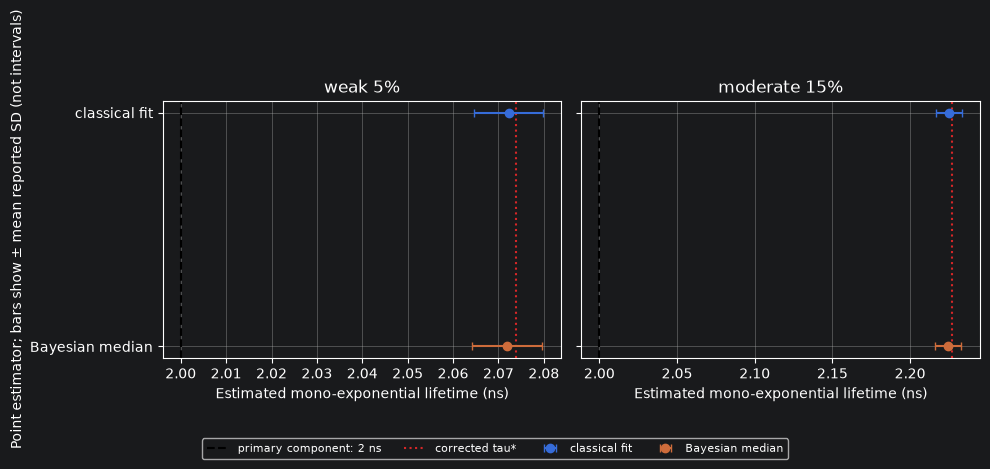

In [13]:
physical_summary = {
    (item['condition_id'], item['assumption_id'], item['method'], item['reference_name']): item
    for item in stage6['summaries']
}
corrected_summary = {
    (item['condition_id'], item['assumption_id'], item['method']): item['corrected']
    for item in correction['reference_dependent_summaries']
}
mismatch_table = []
decomposition = []
for condition_id, label in [('weak_biexponential', 'weak 5%'),
                             ('moderate_biexponential', 'moderate 15%')]:
    tau_star = reference_lookup[(condition_id, 'gaussian_mono')]['lifetime_ns']
    for method in ('covariance', 'bootstrap', 'bayesian'):
        physical = physical_summary[(condition_id, 'gaussian_mono', method, 'primary_component')]
        projected = corrected_summary[(condition_id, 'gaussian_mono', method)]
        assert np.isclose(physical['bias_ns'],
                          projected['bias_ns'] + tau_star - 2.0, atol=1e-10)
        mismatch_table.append({
            'mixture': label, 'interval': method,
            'point estimator': 'Bayesian median' if method == 'bayesian' else 'classical fit',
            'bias vs primary (ns)': physical['bias_ns'],
            'bias vs tau* (ns)': projected['bias_ns'],
            'MAE vs tau* (ns)': projected['mae_ns'],
            'mean reported SD (ns)': physical['mean_reported_std_ns'],
            'primary included': f"{physical['n_reference_included']}/{physical['n_valid_intervals']}",
            'tau* included': f"{projected['n_reference_included']}/{projected['n_valid_intervals']}",
            'physical bias / reported SD': physical['mean_deviation_to_mean_reported_std'],
        })
        if method in ('covariance', 'bayesian'):
            decomposition.append({
                'mixture': label, 'estimator': 'Bayesian median' if method == 'bayesian' else 'classical fit',
                'estimate - primary': physical['bias_ns'],
                'estimate - tau*': projected['bias_ns'],
                'tau* - primary': tau_star - 2.0,
            })
display(pd.DataFrame(mismatch_table).round(6))
display(pd.DataFrame(decomposition).round(6))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (condition_id, label) in zip(axes, [('weak_biexponential', 'weak 5%'),
                                              ('moderate_biexponential', 'moderate 15%')]):
    tau_star = reference_lookup[(condition_id, 'gaussian_mono')]['lifetime_ns']
    ax.axvline(2.0, color='black', linestyle='--', label='primary component: 2 ns')
    ax.axvline(tau_star, color='tab:red', linestyle=':', label='corrected tau*')
    for y, method, name in [(1, 'covariance', 'classical fit'),
                            (0, 'bayesian', 'Bayesian median')]:
        row = physical_summary[(condition_id, 'gaussian_mono', method, 'primary_component')]
        ax.errorbar(2.0 + row['bias_ns'], y, xerr=row['mean_reported_std_ns'],
                    fmt='o', capsize=3, label=name)
    ax.set(xlabel='Estimated mono-exponential lifetime (ns)', title=label,
           yticks=[0, 1], yticklabels=['Bayesian median', 'classical fit'])
axes[0].set_ylabel('Point estimator; bars show ± mean reported SD (not intervals)')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=4, fontsize=8)
fig.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

For the weak 5% mixture ($\tau_1=2$ ns, $\tau_2=4$ ns; fraction of **detected finite-window signal photons**), the Bayesian median is biased +0.071817 ns relative to the primary component but only −0.002105 ns relative to corrected $\tau^\star=2.073921931$ ns. Mean posterior SD is about 0.0077 ns: physical displacement is about nine reported SDs. All three interval methods include the primary lifetime in **0/20**, but include corrected $\tau^\star$ in **16/20**.

At 15% secondary photons, $\tau^\star=2.227022556$ ns, the Bayesian primary bias is +0.224424 ns and pseudo-true bias −0.002599 ns. Reported SD remains about 0.0082–0.0085 ns, so the physical displacement is about 26–27 reported SDs. All three methods give **0/20** primary inclusion and **19/20** corrected pseudo-true inclusion. These 20-run inclusion fractions describe this controlled experiment; they do not establish nominal coverage of a misspecified model.

## 8. Paired IRF-shape mismatch: same counts, different assumption

Stage 6 generated 20 mono-exponential 2 ns histograms with a true asymmetric EMG IRF. Every observation was analysed twice: with the matched EMG and with an Issue-#8 peak/full-FWHM-matched Gaussian. Within each pair the raw histogram, grid, background convention, priors, sampler policy, bootstrap budget, and named random streams are identical. **Only the assumed fixed IRF changes.** The wrong-Gaussian $\tau^\star=2.024957161$ ns predicts the lifetime shift before any Poisson realization is fitted.

,classical shift (ns),Bayesian shift (ns)
mean,0.024976,0.024894
std,0.000484,0.000490
min,0.023896,0.023870
max,0.025861,0.025905


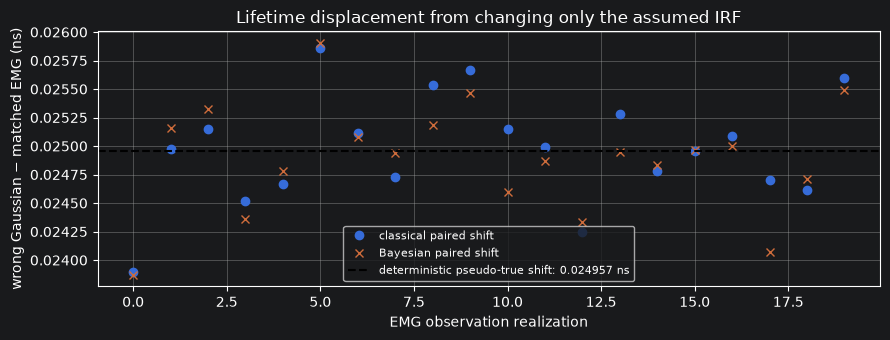

In [14]:
emg_rows = stage6_rows.loc[stage6_rows['condition_id'].eq('emg_irf')].copy()
assert len(emg_rows) == 40
emg_pair = emg_rows.pivot(index='realization_index', columns='assumption_id')
assert len(emg_pair) == 20
for field in ('sample_id', 'observed_counts_sha256', 'time_grid_sha256',
              'seeds_observation', 'seeds_bootstrap', 'seeds_bayesian',
              'seeds_posterior_predictive', 'background_per_bin',
              'true_temporal_shift_ns'):
    assert (emg_pair[field]['matched_emg'] == emg_pair[field]['gaussian_assumed']).all()
assert (emg_pair['assumed_irf_sha256']['matched_emg']
        != emg_pair['assumed_irf_sha256']['gaussian_assumed']).all()
paired_shift = pd.DataFrame({
    'classical shift (ns)': (emg_pair['classical_fit_lifetime_ns']['gaussian_assumed']
                              - emg_pair['classical_fit_lifetime_ns']['matched_emg']),
    'Bayesian shift (ns)': (emg_pair['bayesian_lifetime_median_ns']['gaussian_assumed']
                             - emg_pair['bayesian_lifetime_median_ns']['matched_emg']),
})
display(paired_shift.describe().loc[['mean', 'std', 'min', 'max']].round(6))
predicted_shift = reference_lookup[('emg_irf', 'gaussian_assumed')]['lifetime_ns'] - 2.0
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(paired_shift.index, paired_shift['classical shift (ns)'], 'o', label='classical paired shift')
ax.plot(paired_shift.index, paired_shift['Bayesian shift (ns)'], 'x', label='Bayesian paired shift')
ax.axhline(predicted_shift, color='black', linestyle='--',
           label=f'deterministic pseudo-true shift: {predicted_shift:.6f} ns')
ax.set(xlabel='EMG observation realization', ylabel='wrong Gaussian − matched EMG (ns)',
       title='Lifetime displacement from changing only the assumed IRF')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [15]:
irf_inclusion = []
for method in ('covariance', 'bootstrap', 'bayesian'):
    matched = physical_summary[('emg_irf', 'matched_emg', method, 'generating_mono')]
    wrong = physical_summary[('emg_irf', 'gaussian_assumed', method, 'generating_mono')]
    pseudo = corrected_summary[('emg_irf', 'gaussian_assumed', method)]
    irf_inclusion.append({
        'interval': method,
        'matched EMG: physical 2 ns included': f"{matched['n_reference_included']}/{matched['n_valid_intervals']}",
        'wrong Gaussian: physical 2 ns included': f"{wrong['n_reference_included']}/{wrong['n_valid_intervals']}",
        'wrong Gaussian: tau* included': f"{pseudo['n_reference_included']}/{pseudo['n_valid_intervals']}",
        'matched mean reported SD (ns)': matched['mean_reported_std_ns'],
        'wrong mean reported SD (ns)': wrong['mean_reported_std_ns'],
    })
display(pd.DataFrame(irf_inclusion).round(6))
print('Mean classical paired shift:', round(paired_shift['classical shift (ns)'].mean(), 6), 'ns')
print('Mean Bayesian paired shift:', round(paired_shift['Bayesian shift (ns)'].mean(), 6), 'ns')
print('Pseudo-true shift:', round(predicted_shift, 6), 'ns')
print('A fixed-IRF interval does not propagate uncertainty in IRF shape.')

,interval,matched EMG: physical 2 ns included,wrong Gaussian: physical 2 ns included,wrong Gaussian: tau* included,matched mean reported SD (ns),wrong mean reported SD (ns)
0,covariance,19/20,1/20,19/20,0.007425,0.007508
1,bootstrap,19/20,1/20,19/20,0.007641,0.007417
2,bayesian,19/20,1/20,19/20,0.007453,0.007525


Mean classical paired shift: 0.024976 ns
Mean Bayesian paired shift: 0.024894 ns
Pseudo-true shift: 0.024957 ns
A fixed-IRF interval does not propagate uncertainty in IRF shape.


## 9. Sampling diagnostics are not a test of the physical model

Stage-6 MCMC diagnostics assess numerical sampling of the **assumed** posterior. A chain can mix adequately even when the decay family or IRF is wrong. The single `insufficient_sampling` rejection occurred in the correctly specified mono control, while every deliberately misspecified evaluation passed. These results do not relax the scientific sampler thresholds.

In [16]:
status_table = pd.crosstab(
    [stage6_rows['condition_id'], stage6_rows['assumption_id']],
    stage6_rows['bayesian_status'],
)
display(status_table)
status_counts = stage6_rows['bayesian_status'].value_counts()
assert status_counts.get('success', 0) == 99
assert status_counts.get('insufficient_sampling', 0) == 1
rejected = stage6_rows.loc[stage6_rows['bayesian_status'].ne('success'),
                           ['condition_id', 'assumption_id', 'realization_index',
                            'bayesian_diagnostic_failure_reasons',
                            'bayesian_production_steps']]
display(rejected)
assert rejected.iloc[0]['condition_id'] == 'mono_control'
print('All 60 deliberately misspecified evaluations (weak, moderate, wrong Gaussian) passed the configured sampling policy.')

bayesian_status                          insufficient_sampling  success
condition_id           assumption_id                                   
emg_irf                gaussian_assumed                      0       20
                       matched_emg                           0       20
moderate_biexponential gaussian_mono                         0       20
mono_control           gaussian_mono                         1       19
weak_biexponential     gaussian_mono                         0       20

,condition_id,assumption_id,realization_index,bayesian_diagnostic_failure_reasons,bayesian_production_steps
6,mono_control,gaussian_mono,6,"[""autocorrelation estimate unstable across cha...",5000


All 60 deliberately misspecified evaluations (weak, moderate, wrong Gaussian) passed the configured sampling policy.


## 10. Posterior-predictive checks: strong and weak warnings

The saved Stage-6 PPC used 200 replicated draws per accepted Bayesian fit, with early [1, 3) ns and tail [7, 12) ns windows. Each probability below is the fraction of posterior-predictive replicates with a discrepancy at least as large as observed. It is a **descriptive model-conditional tail fraction**, not a universally calibrated frequentist p-value or a model-validity classifier. Deviance and residual RMS are monotonic transformations in this implementation and must not be counted as independent evidence.

,group,accepted PPC,deviance median,deviance <= 0.05,early <= 0.05,tail <= 0.05,peak >= 0.95
0,matched mono,19,0.335,2,0,0,0
1,weak 5% bi-exp,20,0.385,1,0,6,0
2,moderate 15% bi-exp,20,0.000,20,18,19,0
3,matched EMG,20,0.332,4,0,0,0
4,wrong Gaussian,20,0.000,20,0,0,19


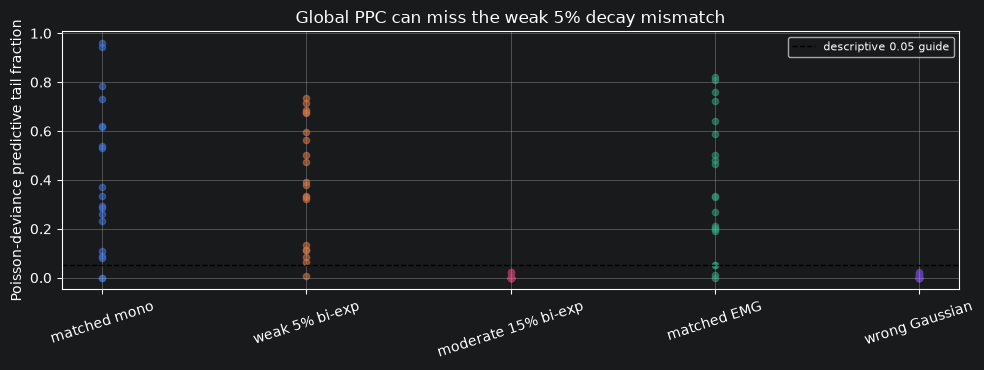

In [17]:
group_order = [
    ('mono_control', 'gaussian_mono', 'matched mono'),
    ('weak_biexponential', 'gaussian_mono', 'weak 5% bi-exp'),
    ('moderate_biexponential', 'gaussian_mono', 'moderate 15% bi-exp'),
    ('emg_irf', 'matched_emg', 'matched EMG'),
    ('emg_irf', 'gaussian_assumed', 'wrong Gaussian'),
]
group_names = {(condition, assumption): label for condition, assumption, label in group_order}
ppc_rows = []
for row in stage6_rows.itertuples(index=False):
    if row.posterior_predictive_status != 'success':
        continue
    discrepancies = {
        name: probability
        for name, observed, replicated_median, probability
        in json.loads(row.posterior_predictive_discrepancy_summaries)
    }
    ppc_rows.append({
        'group': group_names[(row.condition_id, row.assumption_id)],
        'deviance': discrepancies['poisson_deviance'],
        'early counts': discrepancies['early_window_counts'],
        'tail counts': discrepancies['tail_window_counts'],
        'peak counts': discrepancies['peak_counts'],
    })
ppc_frame = pd.DataFrame(ppc_rows)
assert len(ppc_frame) == 99
ppc_table = []
for _, _, label in group_order:
    subset = ppc_frame.loc[ppc_frame['group'].eq(label)]
    ppc_table.append({
        'group': label, 'accepted PPC': len(subset),
        'deviance median': subset['deviance'].median(),
        'deviance <= 0.05': int(subset['deviance'].le(0.05).sum()),
        'early <= 0.05': int(subset['early counts'].le(0.05).sum()),
        'tail <= 0.05': int(subset['tail counts'].le(0.05).sum()),
        'peak >= 0.95': int(subset['peak counts'].ge(0.95).sum()),
    })
display(pd.DataFrame(ppc_table).round(3))
fig, ax = plt.subplots(figsize=(10, 3.8))
for x, (_, _, label) in enumerate(group_order):
    values = ppc_frame.loc[ppc_frame['group'].eq(label), 'deviance']
    ax.scatter(np.full(len(values), x), values, alpha=0.6, s=20)
ax.axhline(0.05, color='black', linestyle='--', lw=1, label='descriptive 0.05 guide')
ax.set(xticks=range(len(group_order)),
       xticklabels=[label for _, _, label in group_order],
       ylabel='Poisson-deviance predictive tail fraction',
       title='Global PPC can miss the weak 5% decay mismatch')
ax.tick_params(axis='x', rotation=18)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

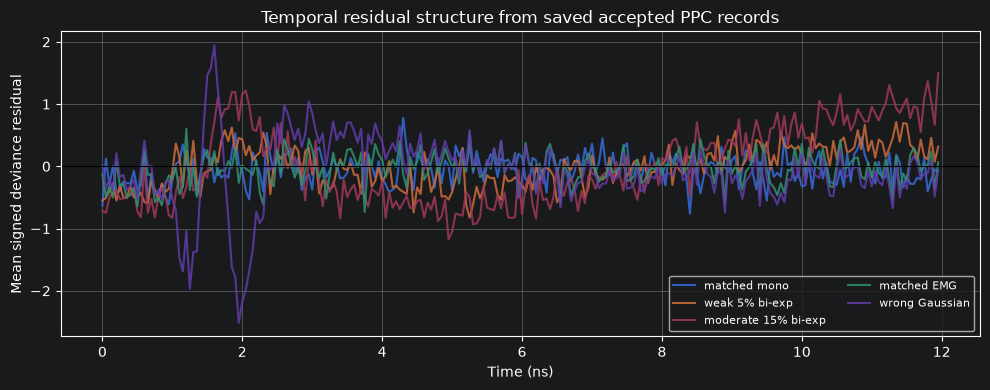

,group,accepted profiles,RMS of across-realization mean signed profile
0,matched mono,19,0.246
1,weak 5% bi-exp,20,0.321
2,moderate 15% bi-exp,20,0.619
3,matched EMG,20,0.252
4,wrong Gaussian,20,0.572


Weak-mismatch residual structure is modestly elevated; moderate decay and wrong-IRF patterns are stronger.


In [18]:
stage6_grid = json.loads(paths['stage6_manifest'].read_text(encoding='utf-8'))['time_grid_ns']
profile_time_ns = np.arange(stage6_grid['start'], stage6_grid['stop'], stage6_grid['step'])
profile_rows = []
fig, ax = plt.subplots(figsize=(10, 4))
for condition_id, assumption_id, label in group_order:
    subset = stage6_rows.loc[
        stage6_rows['condition_id'].eq(condition_id)
        & stage6_rows['assumption_id'].eq(assumption_id)
        & stage6_rows['posterior_predictive_status'].eq('success')
    ]
    profiles = np.stack([
        np.asarray(json.loads(value), dtype=float)
        for value in subset['posterior_predictive_mean_signed_deviance_residual_profile']
    ])
    mean_profile = profiles.mean(axis=0)
    assert mean_profile.shape == profile_time_ns.shape
    rms_mean_profile = float(np.sqrt(np.mean(mean_profile ** 2)))
    profile_rows.append({'group': label, 'accepted profiles': len(profiles),
                         'RMS of across-realization mean signed profile': rms_mean_profile})
    ax.plot(profile_time_ns, mean_profile, label=label, alpha=0.85)
ax.axhline(0.0, color='black', lw=0.8)
ax.set(xlabel='Time (ns)', ylabel='Mean signed deviance residual',
       title='Temporal residual structure from saved accepted PPC records')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
display(pd.DataFrame(profile_rows).round(3))
print('Weak-mismatch residual structure is modestly elevated; moderate decay and wrong-IRF patterns are stronger.')

## 11. Numerical-audit provenance and scientific limits

Scientific computing must distinguish “optimizer reports success” from a numerically validated result. Stage 5.5 found one premature classical L-BFGS-B termination in 480 historical fits and added bounded recovery and failure propagation for **routine noisy-data fits**. Stage 6.5 found that deterministic pseudo-true benchmarks require a stricter contract: a centered Poisson objective, diverse starts including background, tight local descent/gradient checks, and an independent Poisson-deviance cross-check. The original Stage-5/6 CSV/JSON inference artifacts were not rewritten; only Stage-6 reference-dependent summaries were corrected from saved records.

Limitations: 50 baseline Stage-5 repetitions per condition; 20 observations per Stage-6 generating condition; synthetic data; fixed assumed IRF per fit; only predeclared prior-sensitivity variants; finite MCMC budget and operational—not formal—sampling diagnostics; 100 bootstrap refits; 200 Stage-6 PPC replicates; hardware-dependent runtimes; and a pseudo-true lifetime that is model-conditional. No result establishes universal mismatch detection, experimental-data validity, or propagated uncertainty in IRF shape.

## 12. Conclusions

1. With the correct mono-exponential model and fixed IRF, Bayesian posterior uncertainty, local covariance, and parametric bootstrap broadly track repeated-Poisson variability. The 50-repetition Stage-5 coverage estimates have substantial finite-sample uncertainty; Bayesian medians do not materially improve matched-model lifetime MAE.
2. Bayesian inference adds joint parameter correlations and posterior prediction but costs much more on the tested hardware. Its credible interval, the local covariance interval, and the bootstrap percentile interval are all conditional on their assumed physical model.
3. Under bi-exponential or IRF-shape mismatch, the fitted mono-exponential lifetime can be precise around a pseudo-true effective parameter while excluding a physically meaningful generating lifetime. For the same EMG histograms, merely replacing the fixed IRF by a matched-width Gaussian shifts lifetime by about 0.025 ns without materially widening uncertainty.
4. Successful MCMC diagnostics mean the assumed posterior was sampled adequately under the configured policy—not that the physical model is correct. PPC strongly warned for the moderate mixture and wrong IRF, but global deviance scarcely separated the weak mixture from control despite roughly nine reported SDs of physical displacement.
5. Fixed-IRF intervals do not include IRF-shape uncertainty. Model checking, numerical optimization checks, sampler diagnostics, and conditional uncertainty answer different questions.

For the full audit and method-specific interpretation, see [scientific findings](../docs/scientific_findings.md#post-week-9--issue-4-bayesian-poisson-inference-and-model-conditional-uncertainty). This notebook does not rerun the scientific studies.

In [19]:
for name in ('stage5_csv', 'stage5_json', 'stage6_csv', 'stage6_json'):
    assert hashlib.sha256(paths[name].read_bytes()).hexdigest() == sha256[name]
print('Frozen Stage-5/6 artifact hashes still match those read at notebook start.')
print('Scientific manifests:', paths['stage5_manifest'].name, 'and', paths['stage6_manifest'].name)
print('Reference correction:', paths['correction_v1'].name,
      '| generated', correction['provenance']['generated_utc'])
print('No scientific profile, bootstrap study, or scientific Bayesian chain was run by this notebook.')
print('Fresh-kernel notebook cell execution:', round(perf_counter() - notebook_started, 2), 'seconds')

Frozen Stage-5/6 artifact hashes still match those read at notebook start.
Scientific manifests: issue4_bayesian_workflow.json and issue4_bayesian_mismatch_workflow.json
Reference correction: scientific_reference_correction_v1.json | generated 2026-09-30T10:02:17.036268+00:00
No scientific profile, bootstrap study, or scientific Bayesian chain was run by this notebook.
Fresh-kernel notebook cell execution: 9.62 seconds
